<a href="https://www.kaggle.com/code/sonawanelalitsunil/synthetic-tuberculosis-x-ray-dataset-ml-69-55?scriptVersionId=231475246" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tuberculosis-x-ray-dataset-synthetic/tuberculosis_xray_dataset.csv


## Title: Synthetic Tuberculosis X-Ray Dataset

### A collection of AI-generated chest X-rays for tuberculosis detection, useful for medical imaging research and model training.

## import dataset

In [2]:
df = pd.read_csv("/kaggle/input/tuberculosis-x-ray-dataset-synthetic/tuberculosis_xray_dataset.csv")

In [3]:
df.head()

,Patient_ID,Age,Gender,Chest_Pain,Cough_Severity,Breathlessness,Fatigue,Weight_Loss,Fever,Night_Sweats,Sputum_Production,Blood_in_Sputum,Smoking_History,Previous_TB_History,Class
0,PID000001,69,Male,Yes,1,2,3,2.37,Moderate,Yes,Medium,Yes,Former,Yes,Normal
1,PID000002,32,Female,Yes,3,0,9,6.09,Moderate,No,Medium,No,Current,Yes,Normal
2,PID000003,89,Male,No,7,0,3,2.86,Mild,Yes,Medium,No,Current,No,Tuberculosis
3,PID000004,78,Female,Yes,2,0,6,4.57,Moderate,No,High,Yes,Never,Yes,Tuberculosis
4,PID000005,38,Male,No,7,2,5,13.86,High,Yes,Low,No,Never,Yes,Tuberculosis


In [4]:
df.tail()

,Patient_ID,Age,Gender,Chest_Pain,Cough_Severity,Breathlessness,Fatigue,Weight_Loss,Fever,Night_Sweats,Sputum_Production,Blood_in_Sputum,Smoking_History,Previous_TB_History,Class
19995,PID019996,53,Male,No,0,4,6,11.72,Moderate,Yes,Medium,No,Never,Yes,Normal
19996,PID019997,27,Female,No,3,1,1,5.67,Moderate,Yes,Low,Yes,Current,Yes,Tuberculosis
19997,PID019998,23,Male,No,1,2,8,3.91,High,Yes,Low,Yes,Never,No,Normal
19998,PID019999,24,Female,No,8,4,6,8.77,Moderate,Yes,Medium,Yes,Never,Yes,Normal
19999,PID020000,48,Male,No,9,4,4,4.84,High,No,High,No,Never,Yes,Normal


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Patient_ID           20000 non-null  object 
 1   Age                  20000 non-null  int64  
 2   Gender               20000 non-null  object 
 3   Chest_Pain           20000 non-null  object 
 4   Cough_Severity       20000 non-null  int64  
 5   Breathlessness       20000 non-null  int64  
 6   Fatigue              20000 non-null  int64  
 7   Weight_Loss          20000 non-null  float64
 8   Fever                20000 non-null  object 
 9   Night_Sweats         20000 non-null  object 
 10  Sputum_Production    20000 non-null  object 
 11  Blood_in_Sputum      20000 non-null  object 
 12  Smoking_History      20000 non-null  object 
 13  Previous_TB_History  20000 non-null  object 
 14  Class                20000 non-null  object 
dtypes: float64(1), int64(4), object(10)


In [6]:
df.describe()

,Age,Cough_Severity,Breathlessness,Fatigue,Weight_Loss
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,53.467450,4.491350,2.003450,4.508450,7.455280
std,20.773984,2.864723,1.417123,2.881552,4.339864
min,18.000000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,2.000000,1.000000,2.000000,3.640000
50%,53.000000,4.000000,2.000000,5.000000,7.490000
75%,71.000000,7.000000,3.000000,7.000000,11.200000
max,89.000000,9.000000,4.000000,9.000000,15.000000


In [7]:
df.isnull().sum()

Patient_ID             0
Age                    0
Gender                 0
Chest_Pain             0
Cough_Severity         0
Breathlessness         0
Fatigue                0
Weight_Loss            0
Fever                  0
Night_Sweats           0
Sputum_Production      0
Blood_in_Sputum        0
Smoking_History        0
Previous_TB_History    0
Class                  0
dtype: int64

In [8]:
df.dtypes

Patient_ID              object
Age                      int64
Gender                  object
Chest_Pain              object
Cough_Severity           int64
Breathlessness           int64
Fatigue                  int64
Weight_Loss            float64
Fever                   object
Night_Sweats            object
Sputum_Production       object
Blood_in_Sputum         object
Smoking_History         object
Previous_TB_History     object
Class                   object
dtype: object

In [9]:
df.duplicated().sum()

0

In [10]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Chest_Pain', 'Cough_Severity',
       'Breathlessness', 'Fatigue', 'Weight_Loss', 'Fever', 'Night_Sweats',
       'Sputum_Production', 'Blood_in_Sputum', 'Smoking_History',
       'Previous_TB_History', 'Class'],
      dtype='object')

### Data visualizations

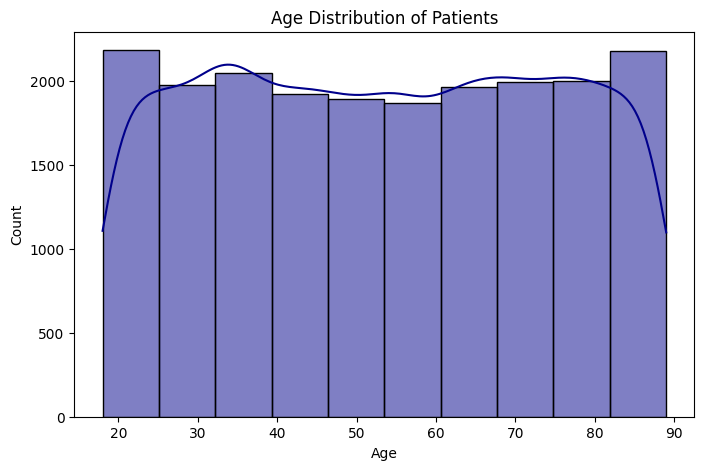

In [11]:
# 1. Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=10, kde=True, color='darkblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


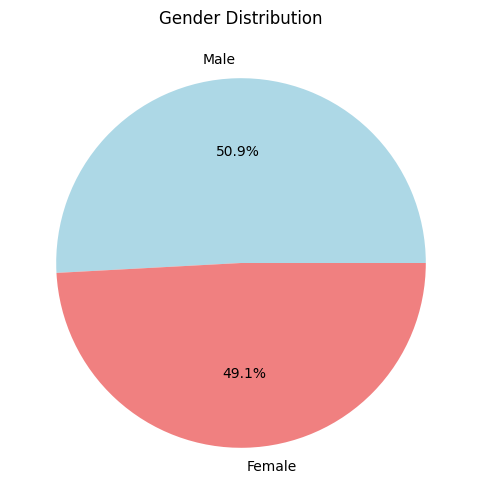

In [12]:
plt.figure(figsize=(6, 6))
df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

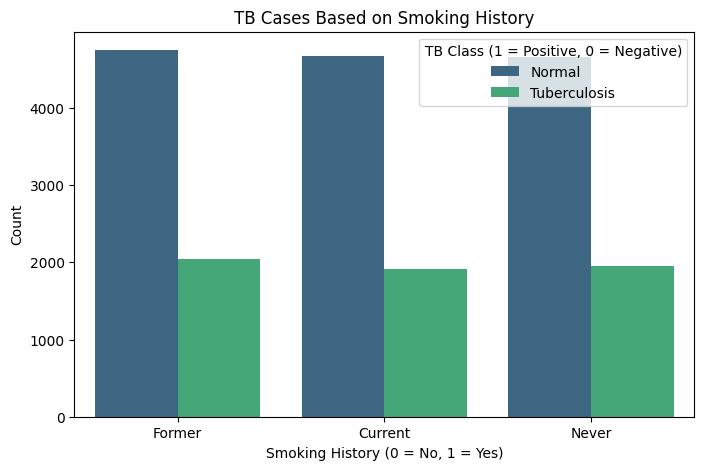

In [13]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Smoking_History', hue='Class', palette='viridis')
plt.title("TB Cases Based on Smoking History")
plt.xlabel("Smoking History (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.legend(title="TB Class (1 = Positive, 0 = Negative)")
plt.show()

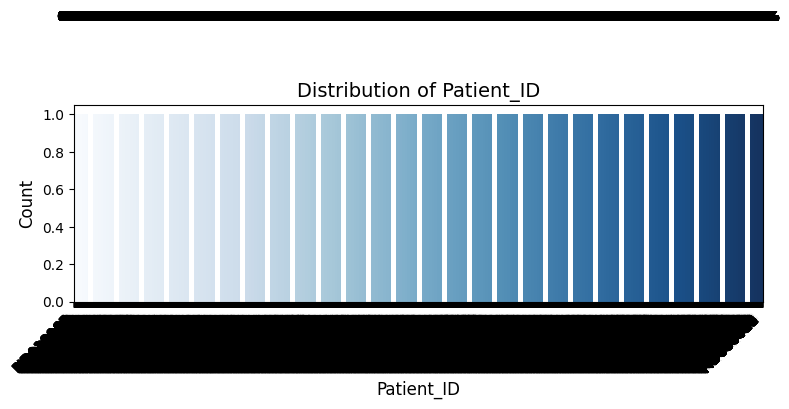

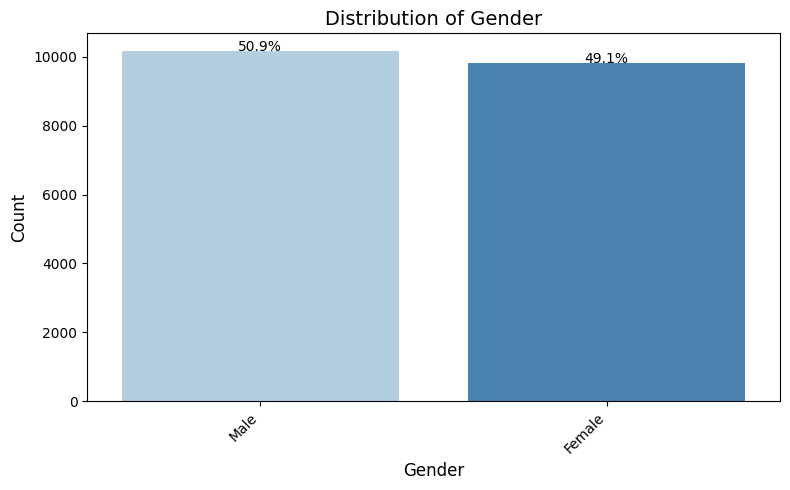

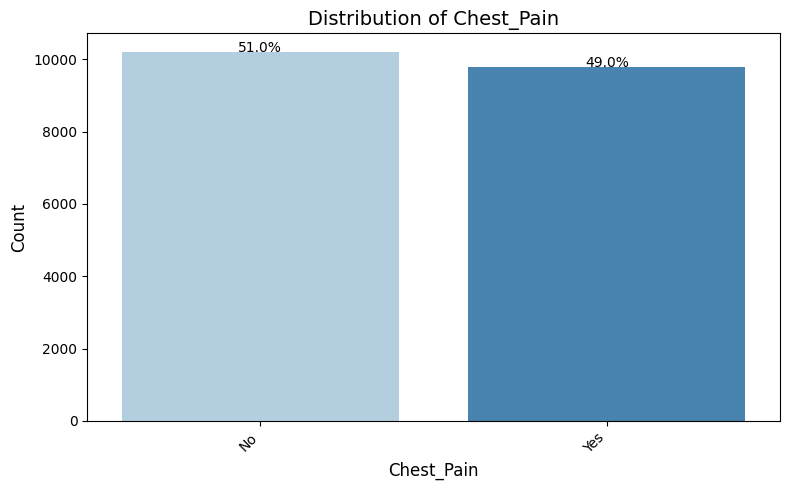

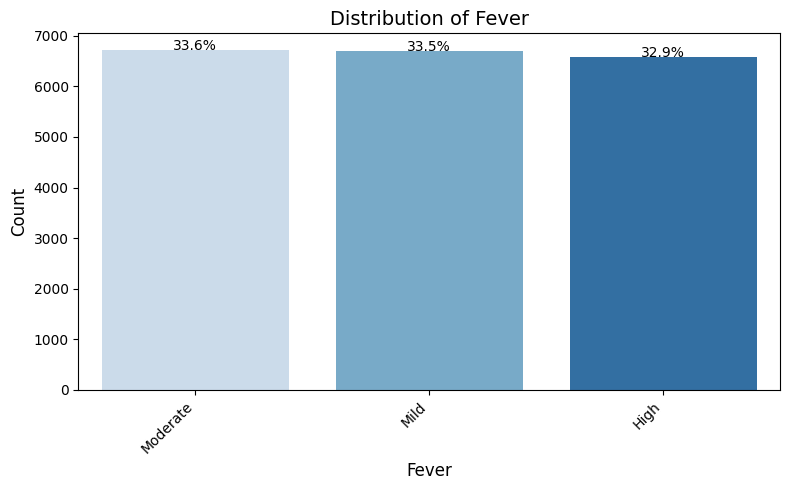

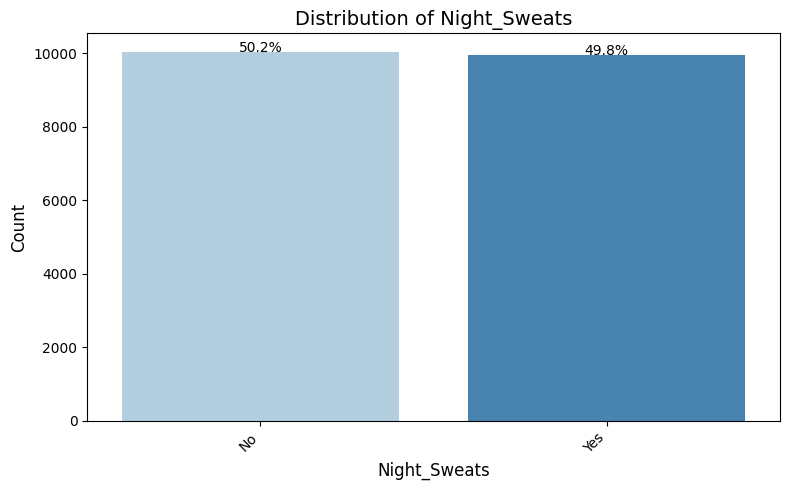

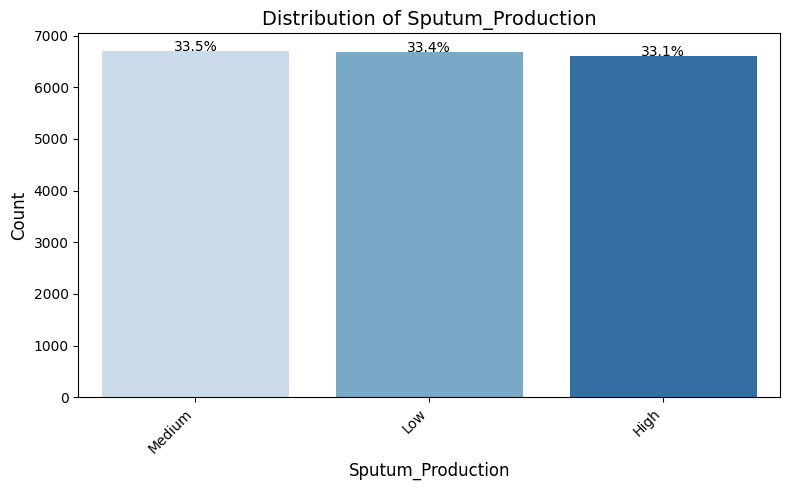

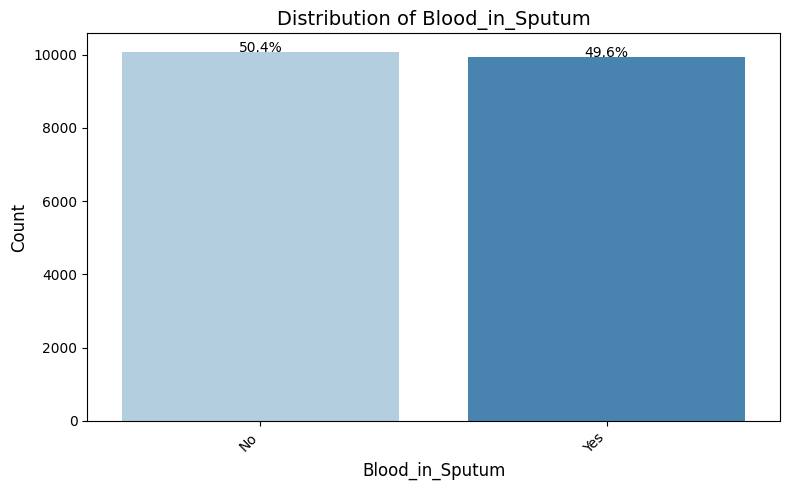

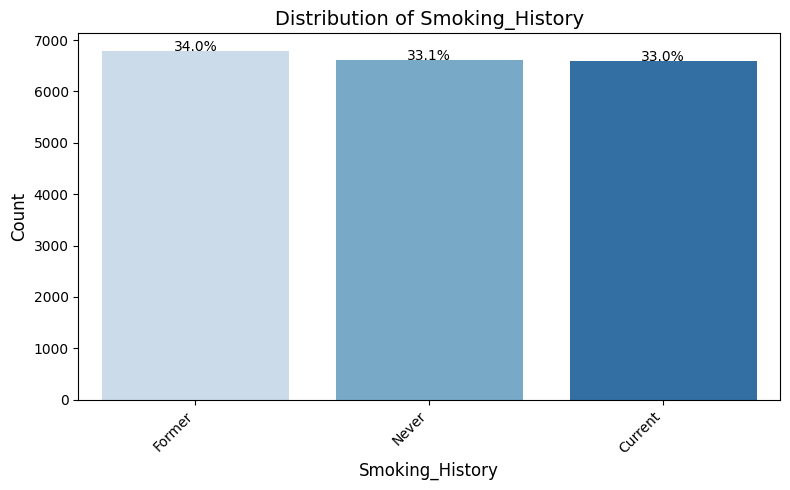

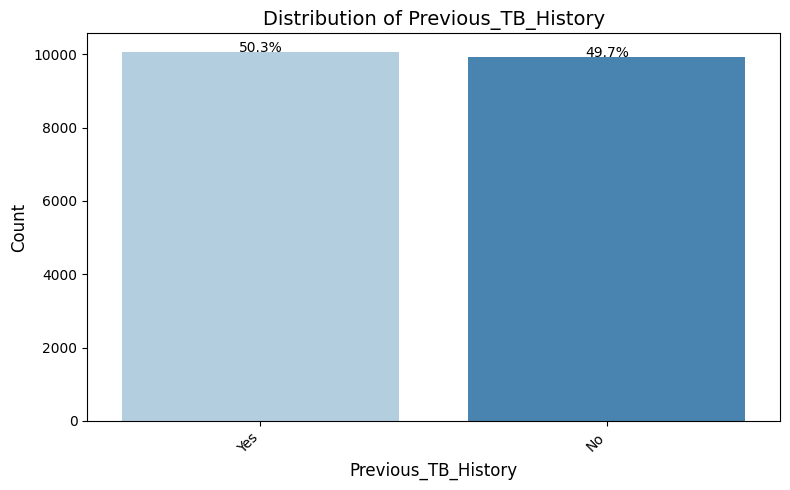

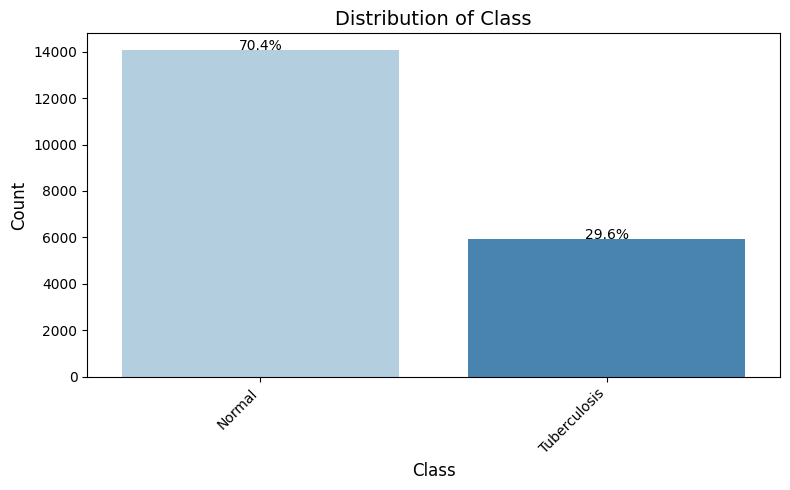

In [14]:
catigorical_col = df.select_dtypes(include='object').columns
for col in catigorical_col:
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(data=df, x=col, palette='Blues', order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    
    # Add percentage labels
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / len(df):.1f}%'
        ax.text(p.get_x() + p.get_width() / 2, p.get_height() + 0.5, percentage, 
                ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

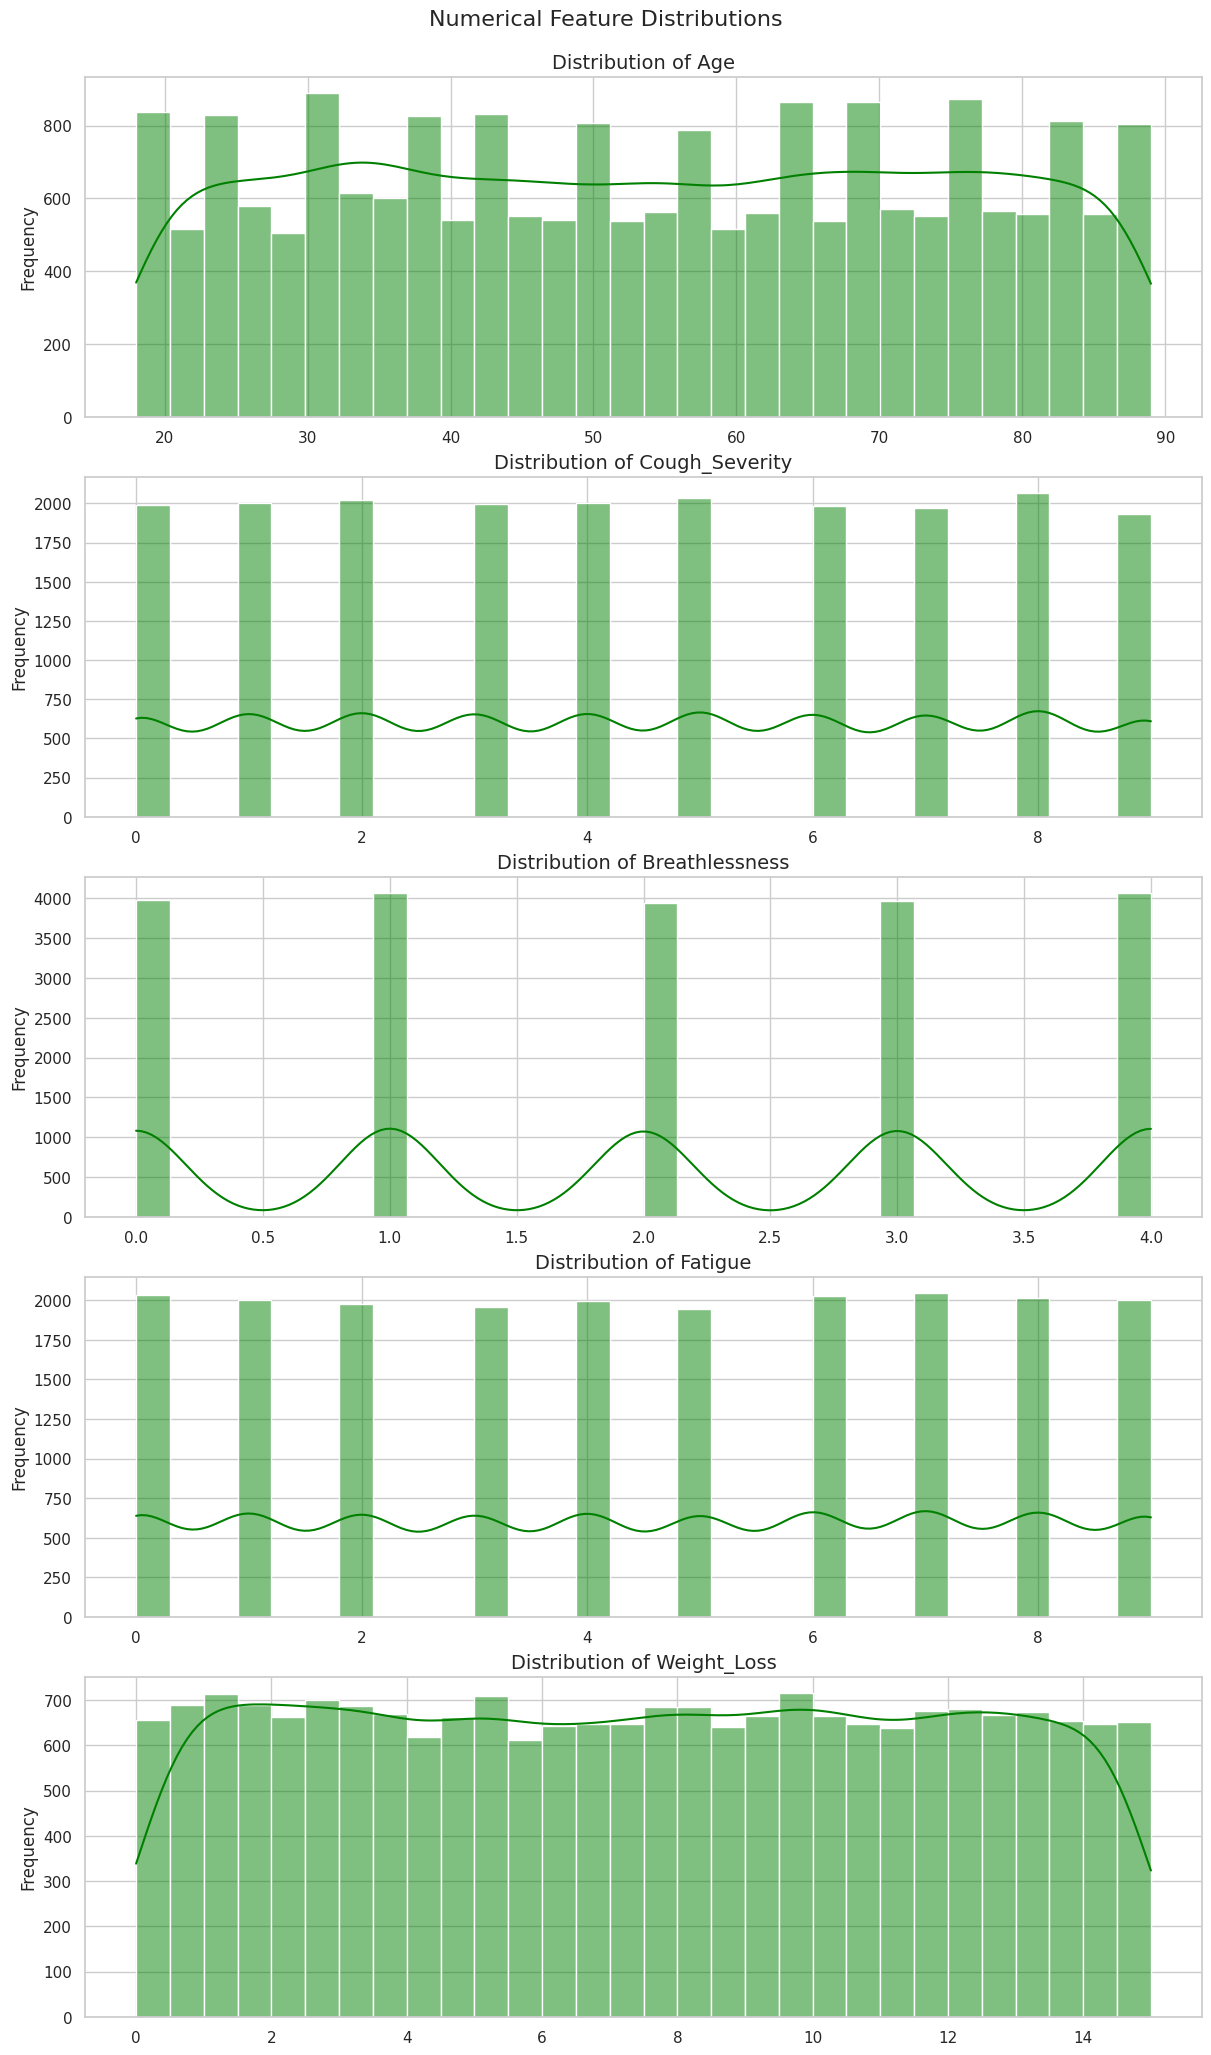

In [15]:
numerical_col = df.select_dtypes(exclude='object').columns
# Set the style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(len(numerical_col), 1, figsize=(12, len(numerical_col) * 4), constrained_layout=True)
for i, col in enumerate(numerical_col):
    sns.histplot(df[col], bins=30, kde=True, color='green', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Numerical Feature Distributions', fontsize=16, y=1.02)
plt.show()

## Predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier

In [17]:
X = df.drop(columns=['Class'])  # Features
y = df['Class']

In [18]:
label_encoders = {}
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

In [19]:
if y.dtype == 'object':
    y_le = LabelEncoder()
    y = y_le.fit_transform(y)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Define ML models
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier()
}

In [22]:
# Train and evaluate models
accuracy_scores = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    accuracy_scores[name] = acc

In [23]:
# Print accuracy scores
print("Model Accuracies (%):")
for model, acc in accuracy_scores.items():
    print(f"{model}: {acc:.2f}%")


Model Accuracies (%):
Logistic Regression: 69.65%
Decision Tree: 57.27%
Random Forest: 69.53%
SVM: 69.65%
Naive Bayes: 69.65%
KNN: 63.22%


In [24]:
# Confusion Matrix for the best model
best_model = max(accuracy_scores, key=accuracy_scores.get)
y_pred_best = models[best_model].predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

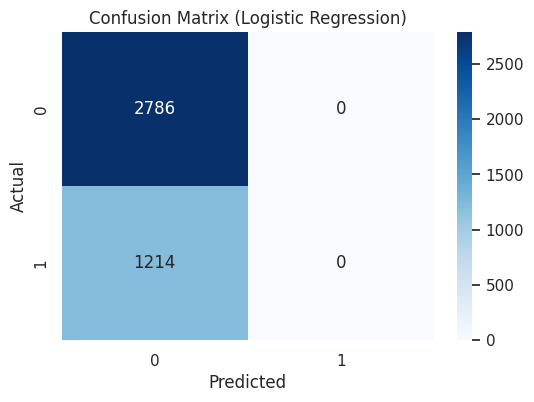

In [25]:
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix ({best_model})")
plt.show()

## Thank you...pls upvote!!!!!